# PCA 降維 (Principal Component Analysis)

學習目標：
- 了解為什麼要降維
- 理解 PCA 的直覺概念
- 用 Python 實作 PCA 並視覺化

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

## 1. 為什麼要降維？

假設你有100個特徵描述一位運動員，
但很多特徵之間高度相關（例如身高和臂展）。

PCA 的做法：
找出「最能代表資料變異」的方向，
把100個特徵壓縮成2~3個「主成分」，
同時保留最多的資訊。

In [3]:
# 載入鳶尾花資料集（4個特徵，3個類別）
iris = load_iris()
X = iris.data
y = iris.target
labels = iris.target_names

print(f'原始資料形狀：{X.shape}')
print(f'特徵名稱：{iris.feature_names}')
print(f'類別：{labels}')

原始資料形狀：(150, 4)
特徵名稱：['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
類別：['setosa' 'versicolor' 'virginica']


In [4]:
# 第一步：標準化（PCA 前必做）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('標準化後均值：', X_scaled.mean(axis=0).round(3))
print('標準化後標準差：', X_scaled.std(axis=0).round(3))

標準化後均值： [-0. -0. -0. -0.]
標準化後標準差： [1. 1. 1. 1.]


In [5]:
# 第二步：PCA 降到2維
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f'降維後形狀：{X_pca.shape}')
print(f'\n各主成分解釋的變異比例：')
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {ratio*100:.1f}%')
print(f'\n兩個主成分合計解釋：{sum(pca.explained_variance_ratio_)*100:.1f}% 的變異')

降維後形狀：(150, 2)

各主成分解釋的變異比例：
  PC1: 73.0%
  PC2: 22.9%

兩個主成分合計解釋：95.8% 的變異


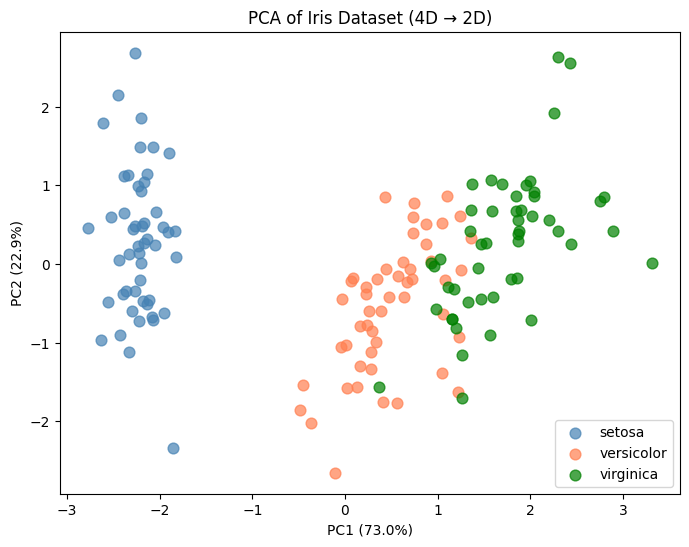

In [6]:
# 第三步：視覺化 PCA 結果
colors = ['steelblue', 'coral', 'green']

plt.figure(figsize=(8, 6))
for i, (label, color) in enumerate(zip(labels, colors)):
    mask = y == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=label, color=color, alpha=0.7, s=60)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA of Iris Dataset (4D → 2D)')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31309 (\N{CJK UNIFIED IDEOGRAPH-7A4D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 37323 (\N{CJK UNIFIED IDEOGRAPH-91CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas

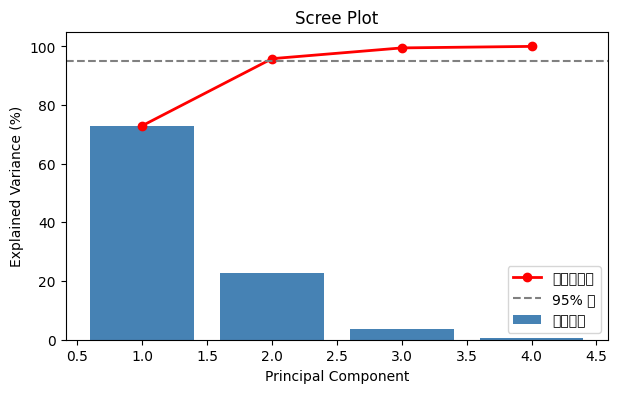

各主成分累積解釋率：
  前 1 個主成分：73.0%
  前 2 個主成分：95.8%
  前 3 個主成分：99.5%
  前 4 個主成分：100.0%


In [7]:
# 第四步：解釋變異比例圖（Scree Plot）
pca_full = PCA()
pca_full.fit(X_scaled)

cumsum = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.bar(range(1, 5), pca_full.explained_variance_ratio_ * 100,
        color='steelblue', label='各主成分')
plt.plot(range(1, 5), cumsum * 100,
         'ro-', linewidth=2, label='累積解釋率')
plt.axhline(y=95, color='gray', linestyle='--', label='95% 線')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Scree Plot')
plt.legend()
plt.show()

print('各主成分累積解釋率：')
for i, c in enumerate(cumsum):
    print(f'  前 {i+1} 個主成分：{c*100:.1f}%')

## 2. 我的學習筆記

1. 這個主題在做什麼：
   PCA 把高維度資料壓縮成低維度，
   保留最多資訊的同時減少特徵數量。

2. 關鍵概念：
   - 主成分：資料變異最大的方向
   - 解釋變異比例：這個主成分保留了多少資訊
   - Scree Plot：幫助決定要保留幾個主成分

3. 我覺得最難理解的地方：
   （填入你自己的想法）

4. 這個跟我研究的連結：
   運動員有很多身體指標（身高、體重、肌力...），
   很多指標互相關聯。
   用 PCA 可以找出最關鍵的幾個「綜合指標」，
   讓預測模型更簡潔有效。